## Part 1

### a
I choose the **MHD64 dataset**.
- **Dimension of discretized data:** 100 timesteps of $64 \times 64 \times 64$  
- **Fields available in the data:**  
  - Density (scalar field)  
  - Velocity (vector field)  
  - Magnetic field (vector field)  
  *(7 channels total, each of size $64 \times 64 \times 64$)*  
- **Number of trajectories:**  
  $10$ initial conditions $\times$ $10$ parameter combinations = $100$ trajectories  
- **Boundary conditions:** periodic boundary conditions  
### b
**Symmetry:** Translational invariance.  
This is natural because the PDEs do not explicitly depend on position. If the system is translated, the equations remain unchanged. Local differential operator does not depend on the position in the space. Also this dataset has the periodic boundary condition.
#### Equation
$$
\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \mathbf{v}) = 0
$$

$$
\frac{\partial (\rho \mathbf{v})}{\partial t} 
+ \nabla \cdot \left( \rho \mathbf{v}\mathbf{v} - \mathbf{B}\mathbf{B} \right) 
+ \nabla p = 0
$$

$$
\frac{\partial \mathbf{B}}{\partial t} 
- \nabla \times (\mathbf{v} \times \mathbf{B}) = 0
$$

## Part 2
### a 
Model ArchitectureThe MHDPredictor is a 3D CNN that acts as an equivariant operator by applying a shared kernel across the spatial grid.
Layers: 
* Input: Conv3d (7 to 32 channels) to extract spatial features.
* Activation: ReLU for non-linearity.
* Output: Conv3d (32 to 7 channels) to project back to physical variables.
* Forward Pass: $x \rightarrow \text{Conv3d} \rightarrow \text{ReLU} \rightarrow \text{Conv3d} \rightarrow \text{Output}$

### b 
b) Translation EquivarianceConvolution ($K$) is equivariant to translation ($T_a$) because shifting the input before convolving is identical to shifting the output after convolving:$$T_a (K \ast f)(x) = K \ast (T_a f)(x)$$Proof:$$(K \ast T_a f)(x) = \int g(y) f(x - y - a) \, dy = T_a (K \ast f)(x)$$This ensures the model treats physical features identically regardless of their position in the simulation box.

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
from torch.utils.data import DataLoader, Dataset, random_split
from the_well.data import WellDataset

In [26]:
BASE_PATH = './datasets'
DATASET = 'MHD_64'
SPLIT = 'train'

def build_dataset() -> WellDataset:
    return WellDataset(
        well_base_path='./datasets/' + BASE_PATH,
        well_dataset_name=DATASET,
        well_split_name="train",
    )

In [43]:
@torch.no_grad()
def visualize_prediction_comparison(
    model: nn.Module,
    dataset: Dataset,
    sample_idx: int = 0,
) -> None:
    model.eval()
    sample = dataset[sample_idx]

    x = sample["input_fields"].squeeze(0).permute(3, 0, 1, 2).unsqueeze(0).float()
    y_true = sample["output_fields"].squeeze(0).permute(3, 0, 1, 2).unsqueeze(0).float()
    y_pred = model(x)

    x_np = x.squeeze(0).cpu().numpy()
    y_true_np = y_true.squeeze(0).cpu().numpy()
    y_pred_np = y_pred.squeeze(0).cpu().numpy()

    field_names = [
        name for group in dataset.dataset.metadata.field_names.values() for name in group
    ] if hasattr(dataset, "dataset") else [
        name for group in dataset.metadata.field_names.values() for name in group
    ]

    z_mid = y_true_np.shape[-1] // 2
    fig, axs = plt.subplots(len(field_names), 3, figsize=(9, 2.2 * len(field_names)), squeeze=False)

    for field_idx, field_name in enumerate(field_names):
        panels = [
            x_np[field_idx, :, :, z_mid],
            y_true_np[field_idx, :, :, z_mid],
            y_pred_np[field_idx, :, :, z_mid],
        ]
        vmin = min(panel.min() for panel in panels)
        vmax = max(panel.max() for panel in panels)

        for col_idx, panel in enumerate(panels):
            axs[field_idx, col_idx].imshow(panel, cmap="RdBu_r", vmin=vmin, vmax=vmax)
            axs[field_idx, col_idx].set_xticks([])
            axs[field_idx, col_idx].set_yticks([])

        axs[field_idx, 0].set_ylabel(field_name, fontsize=10)

    axs[0, 0].set_title("input x")
    axs[0, 1].set_title("true y")
    axs[0, 2].set_title("pred y")
    plt.tight_layout()
    plt.show()

Dataset size: 7623
Dataset path: <WellDataset: ./datasets/./datasets/MHD_64/data/train>


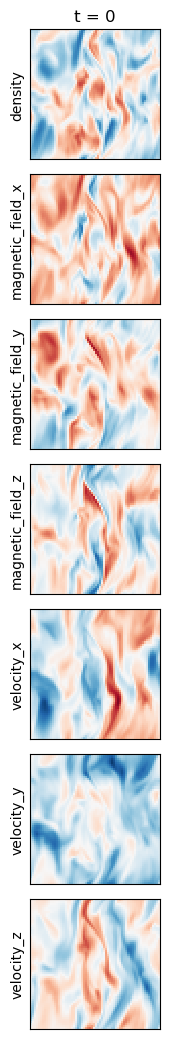

epoch=1 train_total=0.304107 train_mse=0.283532 val_total=0.182859 val_mse=0.165487 val_pde=1.647613 val_bc=0.089652
  new best validation total: 0.182859
epoch=2 train_total=0.193158 train_mse=0.171662 val_total=0.137798 val_mse=0.121770 val_pde=1.503252 val_bc=0.099569
  new best validation total: 0.137798
epoch=3 train_total=0.146948 train_mse=0.128957 val_total=0.111898 val_mse=0.097751 val_pde=1.322956 val_bc=0.091658
  new best validation total: 0.111898


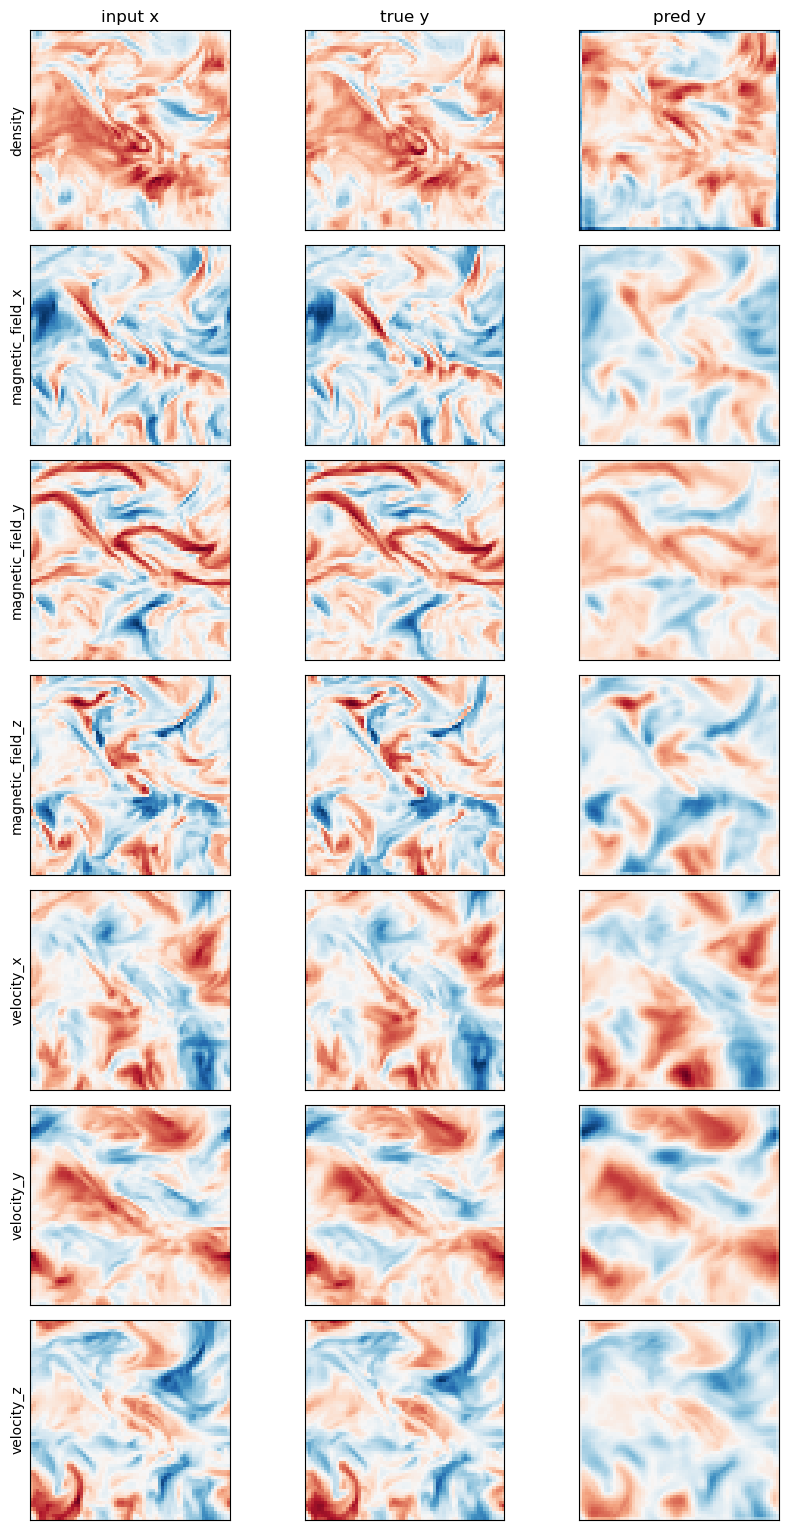

In [45]:
class MHDPredictor(nn.Module):
    def __init__(self, in_channels: int = 7, hidden_channels: int = 32):
        super().__init__()
        self.conv = nn.Conv3d(
            in_channels,
            hidden_channels,
            kernel_size=3,
            padding=1,
            padding_mode="circular",
        )
        self.relu = nn.ReLU()
        self.out = nn.Conv3d(hidden_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.out(self.relu(self.conv(x)))

#x is usually shaped like (batch, channels, x, y, z)
#return: grad_x, grad_y, grad_z = spatial_gradients(x)
def spatial_gradients(x: torch.Tensor, dx: float = 1.0) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    return torch.gradient(x, spacing=dx, dim=(2, 3, 4))


def get_pde_loss_mass(u_now: torch.Tensor, u_next: torch.Tensor, dt: float = 1.0, dx: float = 1.0) -> torch.Tensor:
    rho = u_now[:, 0:1]
    v = u_now[:, 4:7]
    flux = rho * v

    grad_x, grad_y, grad_z = spatial_gradients(flux, dx=dx)
    div_flux = grad_x[:, 0:1] + grad_y[:, 1:2] + grad_z[:, 2:3]
    drho_dt = (u_next[:, 0:1] - u_now[:, 0:1]) / dt
    return torch.mean((drho_dt + div_flux) ** 2)


def get_pde_loss_momentum(u_now: torch.Tensor, u_next: torch.Tensor, dt: float = 1.0, dx: float = 1.0) -> torch.Tensor:
    rho = u_now[:, 0:1]
    v = u_now[:, 4:7]
    b_field = u_now[:, 1:4]

    mom = rho * v
    dmom_dt = (u_next[:, 0:1] * u_next[:, 4:7] - mom) / dt

    v_sq = torch.sum(v ** 2, dim=1, keepdim=True)
    b_sq = torch.sum(b_field ** 2, dim=1, keepdim=True)
    p_eff = rho * v_sq - b_sq + rho

    grad_x, grad_y, grad_z = spatial_gradients(p_eff, dx=dx)
    grad_p = torch.cat([grad_x, grad_y, grad_z], dim=1)#make one channel to three channel
    return torch.mean((dmom_dt + grad_p) ** 2)


def get_induction_loss(u_now: torch.Tensor, u_next: torch.Tensor, dt: float = 1.0, dx: float = 1.0) -> torch.Tensor:
    v = u_now[:, 4:7]
    b_field = u_now[:, 1:4]
    v_cross_b = torch.cross(v, b_field, dim=1)

    grad_x, grad_y, grad_z = spatial_gradients(v_cross_b, dx=dx)
    curl_x = grad_y[:, 2:3] - grad_z[:, 1:2]##grad_y[:, 2:3]=partial fz/partial y,[2:3] means fz
    curl_y = grad_z[:, 0:1] - grad_x[:, 2:3]
    curl_z = grad_x[:, 1:2] - grad_y[:, 0:1]

    #combines the three (B, 1, X, Y, Z) into one 3-channel (B, 3, X, Y, Z)
    curl_v_cross_b = torch.cat([curl_x, curl_y, curl_z], dim=1)

    db_dt = (u_next[:, 1:4] - u_now[:, 1:4]) / dt
    return torch.mean((db_dt - curl_v_cross_b) ** 2)


def total_pde_loss(u_now: torch.Tensor, u_next: torch.Tensor, dt: float = 1.0, dx: float = 1.0) -> torch.Tensor:
    return (
        get_pde_loss_mass(u_now, u_next, dt=dt, dx=dx)
        + get_pde_loss_momentum(u_now, u_next, dt=dt, dx=dx)
        + get_induction_loss(u_now, u_next, dt=dt, dx=dx)
    )

#nn.Conv3d expects input in the form:(batch, channels, depth, height, width)
def prepare_batch(batch: dict[str, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor]:
    x = batch["input_fields"].squeeze(1).permute(0, 4, 1, 2, 3).float()
    y = batch["output_fields"].squeeze(1).permute(0, 4, 1, 2, 3).float()
    return x, y
    
#in the loss_pde part, it is like using the x(current physics state)
#to act like a u_now to predict u_next
def train_one_step(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    batch: dict[str, torch.Tensor],
    lambda_pde: float = 0.01,
    lambda_bc: float = 0.01,
) -> dict[str, float]:
    model.train()
    optimizer.zero_grad()

    x, y_true = prepare_batch(batch)
    y_pred = model(x)

    loss_mse = F.mse_loss(y_pred, y_true)
    loss_pde = total_pde_loss(x, y_pred, dt=1.0, dx=1.0)
    loss_bc = (
        F.mse_loss(y_pred[:, :, 0, :, :], y_pred[:, :, -1, :, :])
        + F.mse_loss(y_pred[:, :, :, 0, :], y_pred[:, :, :, -1, :])
        + F.mse_loss(y_pred[:, :, :, :, 0], y_pred[:, :, :, :, -1])
    )
    total_loss = loss_mse + lambda_pde * loss_pde + lambda_bc * loss_bc

    total_loss.backward()
    optimizer.step()

    return {
        "total": float(total_loss.item()),
        "mse": float(loss_mse.item()),
        "pde": float(loss_pde.item()),
        "bc": float(loss_bc.item()),
    }

##The evaluate function is for measuring, for evaluation
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    lambda_pde: float = 0.01,
    lambda_bc: float = 0.01,
) -> dict[str, float]:
    model.eval()
    totals = {"total": 0.0, "mse": 0.0, "pde": 0.0, "bc": 0.0}
    num_batches = 0

    for batch in loader:
        x, y_true = prepare_batch(batch)
        y_pred = model(x)

        loss_mse = F.mse_loss(y_pred, y_true)
        loss_pde = total_pde_loss(x, y_pred, dt=1.0, dx=1.0)
        loss_bc = (
            F.mse_loss(y_pred[:, :, 0, :, :], y_pred[:, :, -1, :, :])
            + F.mse_loss(y_pred[:, :, :, 0, :], y_pred[:, :, :, -1, :])
            + F.mse_loss(y_pred[:, :, :, :, 0], y_pred[:, :, :, :, -1])
        )
        total_loss = loss_mse + lambda_pde * loss_pde + lambda_bc * loss_bc

        totals["total"] += float(total_loss.item())
        totals["mse"] += float(loss_mse.item())
        totals["pde"] += float(loss_pde.item())
        totals["bc"] += float(loss_bc.item())
        num_batches += 1

    return {name: value / num_batches for name, value in totals.items()}

## This is for seperating the dataset into training and validation set
def build_train_val_loaders(
    dataset: Dataset,
    batch_size: int = 2,
    val_fraction: float = 0.1,
    seed: int = 0,
) -> tuple[DataLoader, DataLoader]:
    val_size = max(1, int(len(dataset) * val_fraction))
    train_size = len(dataset) - val_size
    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

    
def visualize_sample(dataset: WellDataset, sample_idx: int = 42) -> None:
    field_names = [
        name for group in dataset.metadata.field_names.values() for name in group
    ]

    raw_x = dataset[sample_idx]["input_fields"]
    x = rearrange(raw_x, "T Lx Ly Lz F -> F T Lx Ly Lz")
    n_fields, n_times = x.shape[:2]
    z_mid = x.shape[-1] // 2

    fig, axs = plt.subplots(
        n_fields,
        n_times,
        figsize=(n_times * 2.4, n_fields * 1.5),
        squeeze=False,
    )

    for field in range(n_fields):
        vmin, vmax = np.nanmin(x[field]), np.nanmax(x[field])
        axs[field, 0].set_ylabel(field_names[field], fontsize=10)
        for t in range(n_times):
            slice_data = x[field, t, :, :, z_mid]
            axs[field, t].imshow(
                slice_data,
                cmap="RdBu_r",
                interpolation="nearest",
                vmin=vmin,
                vmax=vmax,
            )
            axs[field, t].set_xticks([])
            axs[field, t].set_yticks([])
            if field == 0:
                axs[field, t].set_title(f"t = {t}")

    plt.tight_layout()
    plt.show()


def main() -> None:
    dataset = build_dataset()
    print(f"Dataset size: {len(dataset)}")
    print(f"Dataset path: {dataset}")

    visualize_sample(dataset)

    train_loader, val_loader = build_train_val_loaders(dataset, batch_size=2, val_fraction=0.1, seed=42)
    model = MHDPredictor().to()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    num_epochs = 3
    max_train_steps_per_epoch = 5
    best_val_total = float("inf")

    for epoch in range(1, num_epochs + 1):
        train_totals = {"total": 0.0, "mse": 0.0, "pde": 0.0, "bc": 0.0}
        train_steps = 0

        for step, batch in enumerate(train_loader, start=1):
            metrics = train_one_step(model, optimizer, batch)
            for name, value in metrics.items():
                train_totals[name] += value
            train_steps += 1

            if step >= max_train_steps_per_epoch:
                break

        train_metrics = {name: value / train_steps for name, value in train_totals.items()}
        val_metrics = evaluate(model, val_loader)

        print(
            f"epoch={epoch} "
            f"train_total={train_metrics['total']:.6f} train_mse={train_metrics['mse']:.6f} "
            f"val_total={val_metrics['total']:.6f} val_mse={val_metrics['mse']:.6f} "
            f"val_pde={val_metrics['pde']:.6f} val_bc={val_metrics['bc']:.6f}"
        )

        if val_metrics["total"] < best_val_total:
            best_val_total = val_metrics["total"]
            print(f"  new best validation total: {best_val_total:.6f}")
            
    show_prediction_check = True
    if show_prediction_check:
        visualize_prediction_comparison(model, val_loader.dataset, sample_idx=0)


if __name__ == "__main__":
    main()

## Part 3
Using fully connected MLP as a comparision

1. The MLP has no "bias" toward translation. If we shift the input plasma density by one pixel, the MLP has to learn from scratch what that means for every single weight.
2. Because the MLP doesn't use Weight Sharing, it needs a massive number of parameters just to "see" the whole grid.
3. By flattening the $64 \times 64 \times 64$ cube, the model loses the concept of "neighboring pixels," which is essential for solving PDEs.

In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class MLP(nn.Module):
    def __init__(self, input_size=7, hidden_size=256, output_size=7):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LeakyReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        """
        Handles 5D MHD data: (B, 7, D, H, W)
        Returns: (B, 7, D, H, W)
        """
        if x.dim() == 5:
            B, C, D, H, W = x.shape
            x = x.permute(0, 2, 3, 4, 1).reshape(-1, C)
            
            out = self.net(x)
            
            out = out.view(B, D, H, W, C).permute(0, 4, 1, 2, 3)
            return out
        else:
            return self.net(x)

# Initialize
modelMLP = MLP(input_size=7, hidden_size=256, output_size=7)
optimizer = optim.Adam(modelMLP.parameters(), lr=1e-4)
criterion = nn.MSELoss()

dataset = build_dataset()
train_loader, val_loader = build_train_val_loaders(dataset, batch_size=2, val_fraction=0.1, seed=42)

def run_optimization(num_epochs, loader, model, optimizer, criterion):
    model.train()
    loss_history = []
    
    for epoch in range(num_epochs):
        total_loss = 0
        for data, target in loader:
            optimizer.zero_grad()
            
            output = model(data)
            loss = criterion(output, target)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {avg_loss:.6f}")
            
    return loss_history

losses1 = run_optimization(100, train_loader, modelMLP, optimizer, criterion)

modelMLP.eval()
with torch.no_grad():
    test_data, test_target = next(iter(train_loader))
    prediction = modelMLP(test_data)

plt.figure(figsize=(10, 5))
plt.plot(test_target[0, 0].flatten().numpy()[:100], 'o', label='True', alpha=0.6)
plt.plot(prediction[0, 0].flatten().numpy()[:100], 'x', label='MLP Prediction', alpha=0.6)
plt.legend()
plt.title("MHD Variable Prediction")
plt.show()

ValueError: too many values to unpack (expected 2)

# Reference

https://www.geeksforgeeks.org/deep-learning/convolutional-neural-network-cnn-in-machine-learning/

https://polymathic-ai.org/the_well/datasets/MHD_64/

https://chatgpt.com/

https://maurice-weiler.gitlab.io/cnn_book/EquivariantAndCoordinateIndependentCNNs.pdf